# Exploracion de datos y Acondicionamiento
## Carga del Dataset

In [1]:
from os import makedirs, path, system
import pandas as pd

FILE_PATH = './data/eeg_eye_state.csv'

if not path.exists(FILE_PATH):
    print("El archivo no existe localmente. Verificando dependencias...")

    try:
        from ucimlrepo import fetch_ucirepo
    except ImportError:
        print("Instalando ucimlrepo...")

        # Instalacion del paquete UCI
        from IPython import get_ipython
        if get_ipython():
            # Para notebook
            get_ipython().run_line_magic('pip', 'install ucimlrepo')
        else:
            # Para script
            system('pip install ucimlrepo')
        
        from ucimlrepo import fetch_ucirepo

    print("Iniciando descarga desde UCI Repo...")
    eeg_eye_state = fetch_ucirepo(id=264)
    df = pd.concat([eeg_eye_state.data.features, eeg_eye_state.data.targets], axis=1)
    
    # Guardar datos del dataset
    makedirs(os.path.dirname(FILE_PATH), exist_ok=True)
    df.to_csv(FILE_PATH, index=False)
    print(f"Datos guardados en: {FILE_PATH}")

else:
    # Los datos ya existen
    df = pd.read_csv(FILE_PATH)
    print(f"Los datos ya existen en {FILE_PATH}")

Los datos ya existen en ./data/eeg_eye_state.csv


In [2]:
FS = 128  # Frecuencia de muestreo en Hz
CHANNELS = ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']
TARGET_COL = 'eyeDetection' # 0: ojos abiertos, 1: ojos cerrados
df['time_sec'] = range(len(df))
df['time_sec'] = df['time_sec'] / FS
display(df.head())

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection,time_sec
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85,0,0.000000
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10,0,0.007812
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23,0,0.015625
3,4328.72,4011.79,4296.41,4155.90,4343.59,4582.56,4097.44,4630.77,4217.44,4235.38,4210.77,4287.69,4632.31,4396.41,0,0.023438
4,4326.15,4011.79,4292.31,4151.28,4347.69,4586.67,4095.90,4627.69,4210.77,4244.10,4212.82,4288.21,4632.82,4398.46,0,0.031250


## Analisis exploratorio

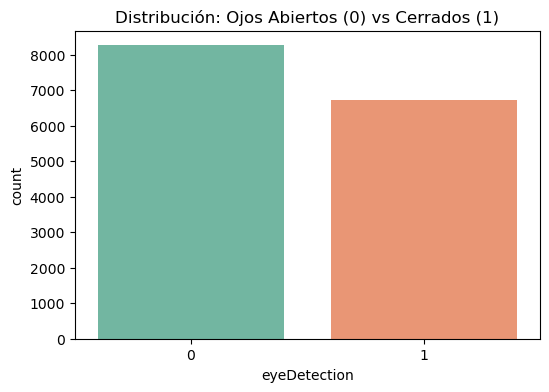

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(
    data=df,
    x=TARGET_COL,
    hue=TARGET_COL,
    palette='Set2',
    legend=False
)
plt.title('Distribución: Ojos Abiertos (0) vs Cerrados (1)')
plt.show()

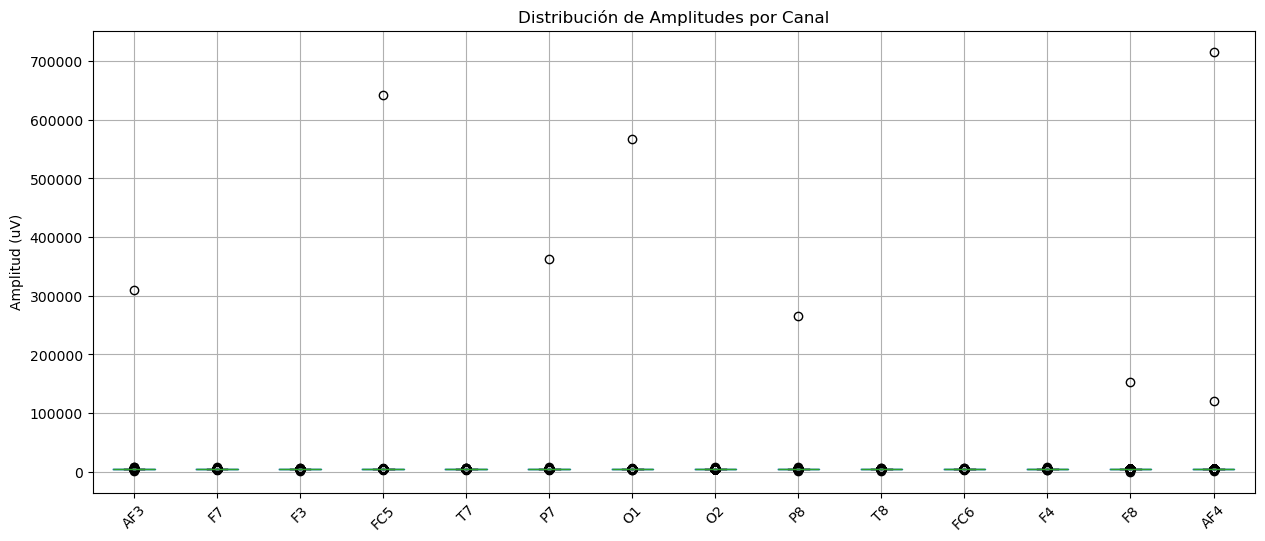

In [4]:
plt.figure(figsize=(15, 6))
df[CHANNELS].boxplot()
plt.title('Distribución de Amplitudes por Canal')
plt.ylabel('Amplitud (uV)')
plt.xticks(rotation=45)
plt.show()

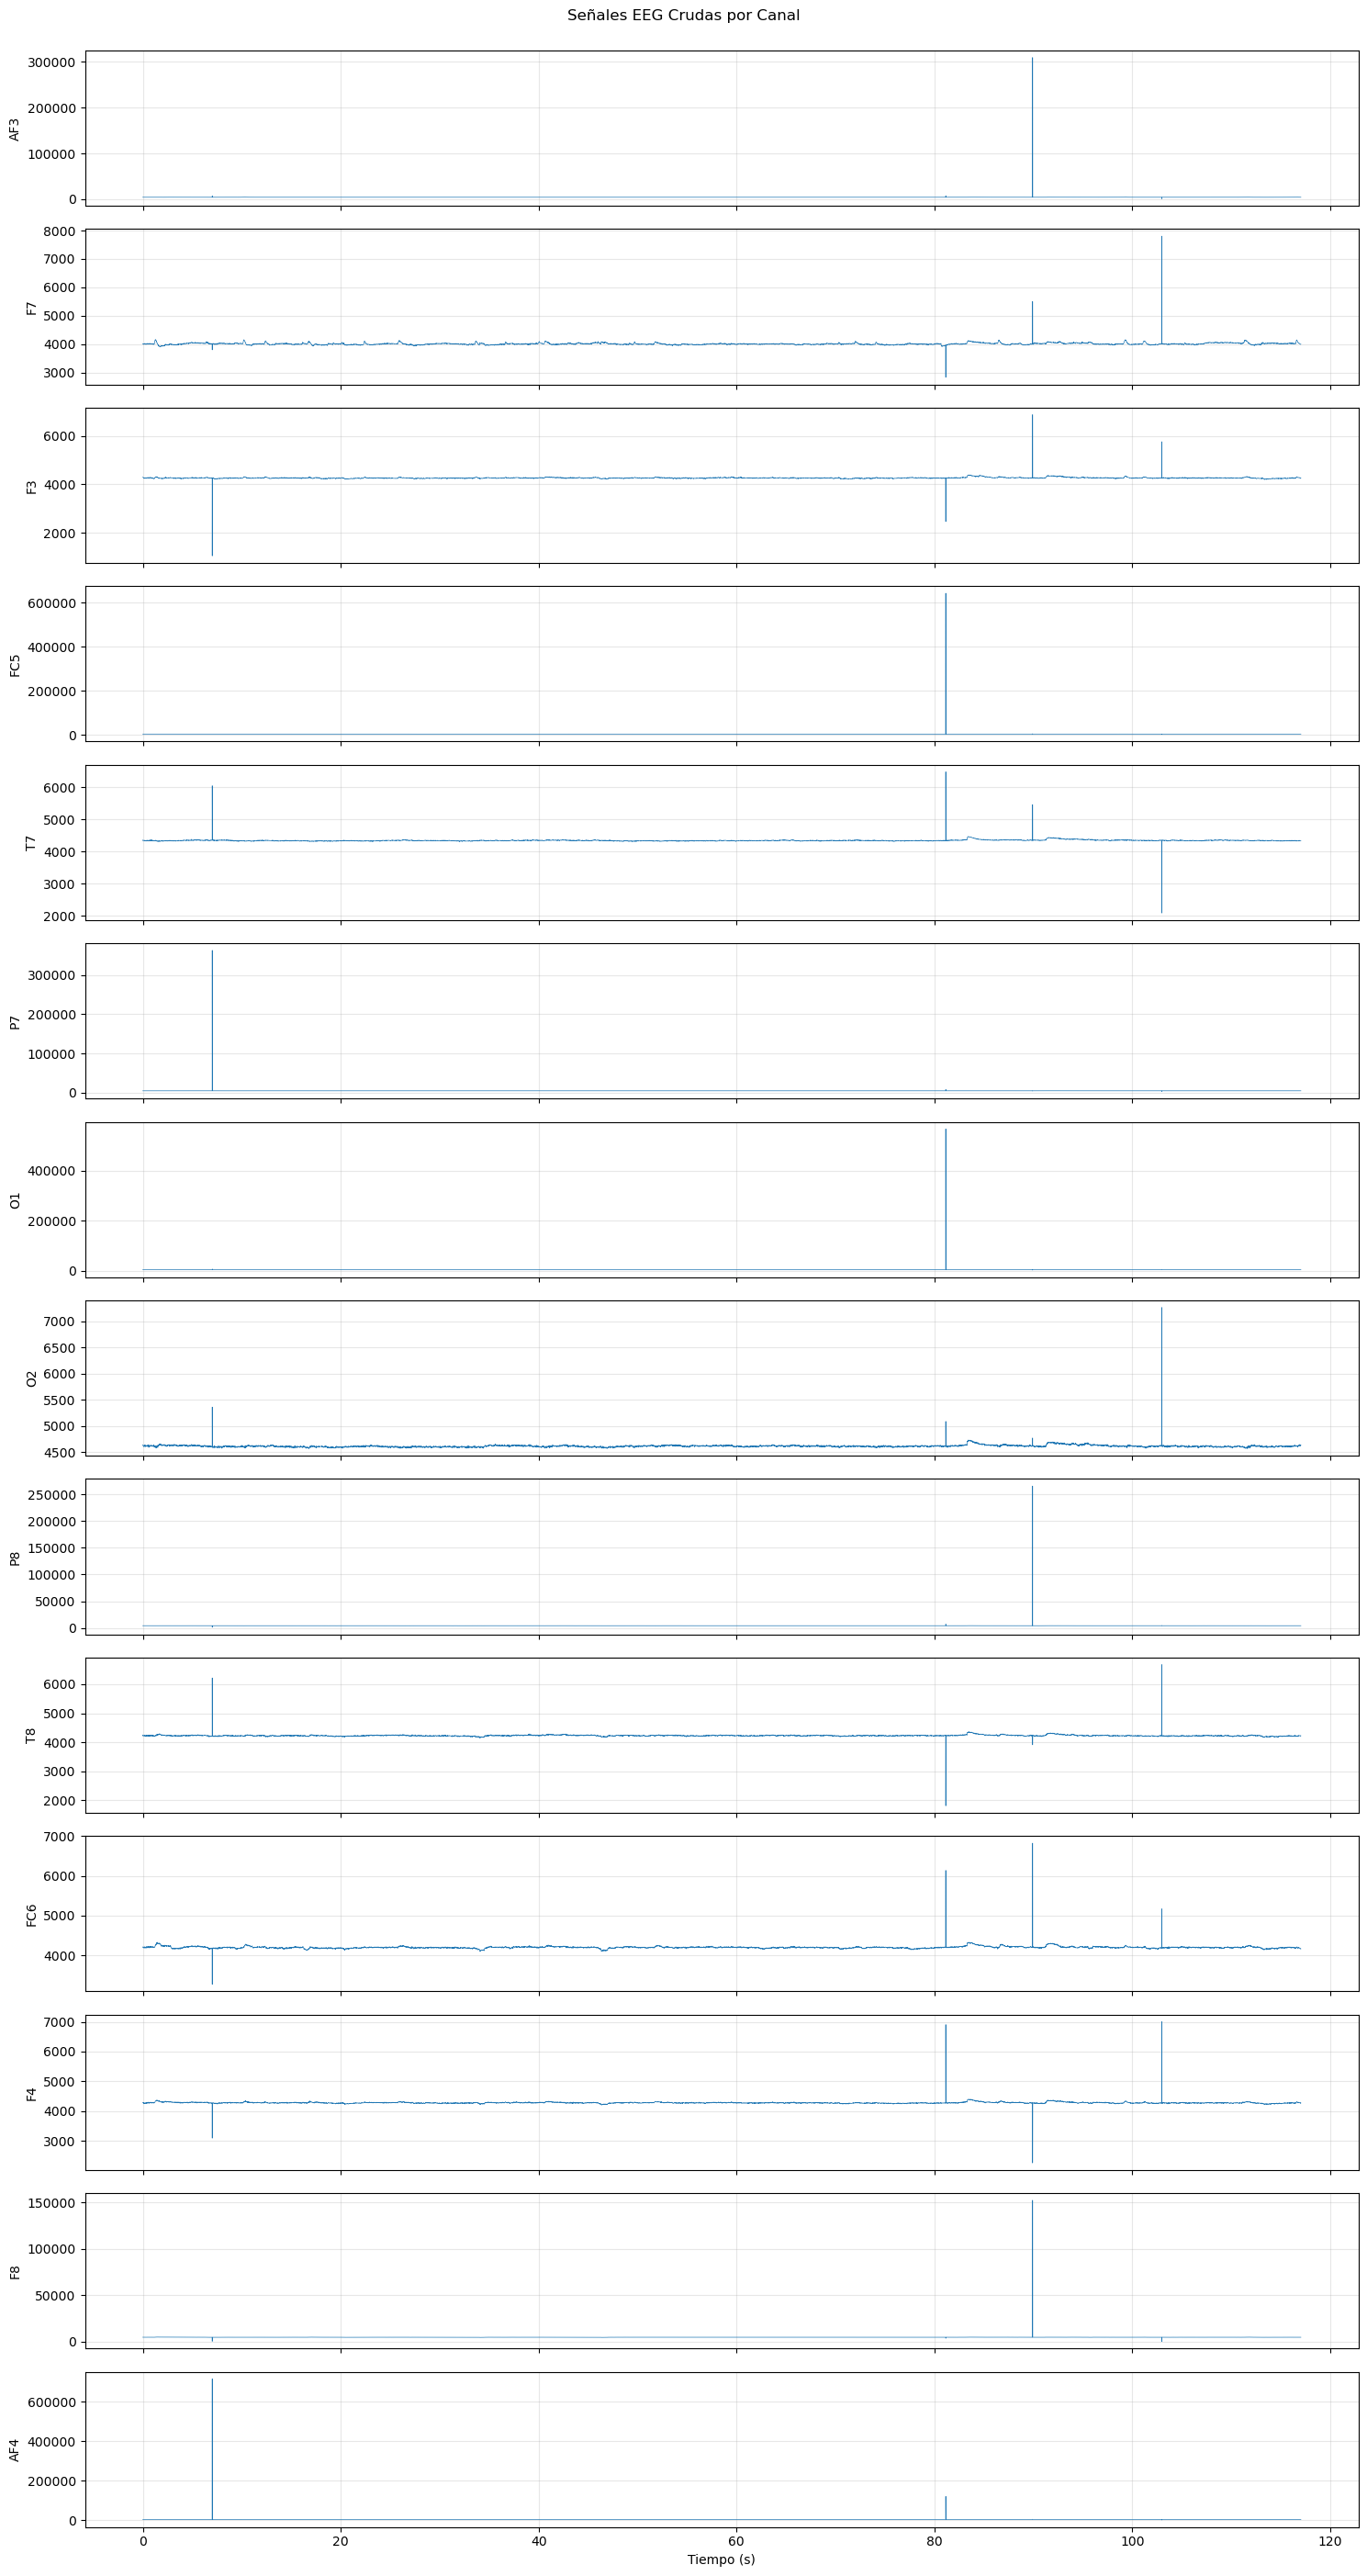

In [5]:
n_channels = len(CHANNELS)
fig, axes = plt.subplots(n_channels, 1, figsize=(15, 2 * n_channels), sharex=True)

for i, ch in enumerate(CHANNELS):
    axes[i].plot(df['time_sec'], df[ch], lw=0.5)
    axes[i].set_ylabel(ch)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Tiempo (s)')
fig.suptitle('Señales EEG Crudas por Canal', y=1)
plt.tight_layout()
plt.show()

## Acondicionamiento

In [6]:
# Celda final para guardar los datos acondicionados
# df_clean = df
# df_clean.to_csv("./data/egg_eye_state_clean.csv")